In [1]:
# CODIGO PARA SIMULACIONES NOMINALES (vuelo vertical sin viento a nivel del mar, para calcular esfuerzos maximos)

from rocketpy import Rocket, Environment, SolidMotor, GenericMotor, Flight

--------------------------------------------------------------------------------
Fetching elevation from open-elevation.com for lat=41.73007275912096, lon=0.10426577877432051...


C:\Users\julfe\anaconda3\Lib\site-packages\rocketpy\mathutils\function.py:3125: UserWarning: Extrapolation method set to 'constant' because the linear method is not supported.
  warnings.warn(


Elevation received:  210.0

Gravity Details

Acceleration of gravity at surface level:    9.8026 m/s²
Acceleration of gravity at  80.000 km (ASL): 9.5610 m/s²


Launch Site Details

Launch Site Latitude: 41.73007°
Launch Site Longitude: 0.10427°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 758186.13 E    4624465.15 N
Launch Site UTM zone: 30T
Launch Site Surface Elevation: 210.0 m


Atmospheric Model Details

Atmospheric Model Type: standard_atmosphere
standard_atmosphere Maximum Height: 80.000 km

Surface Atmospheric Conditions

Surface Wind Speed: 0.00 m/s
Surface Wind Direction: 0.00°
Surface Wind Heading: 0.00°
Surface Pressure: 988.62 hPa
Surface Temperature: 286.79 K
Surface Air Density: 1.201 kg/m³
Surface Speed of Sound: 339.43 m/s


Earth Model Details

Earth Radius at Launch site: 6368.71 km
Semi-major Axis: 6378.14 km
Semi-minor Axis: 6356.75 km
Flattening: 0.0034


Atmospheric Model Plots



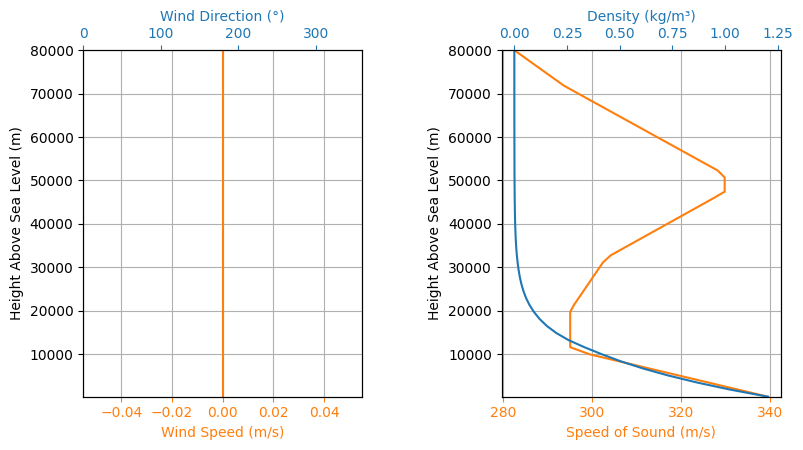

--------------------------------------------------------------------------------
Motor Details
Total Burning Time: 6.2 s
Total Propellant Mass: 0.350 kg
Average Propellant Exhaust Velocity: 1727.080 m/s
Average Thrust: 97.496 N
Maximum Thrust: 332.429 N at 0.043 s after ignition.
Total Impulse: 604.478 Ns



C:\Users\julfe\anaconda3\Lib\site-packages\rocketpy\motors\motor.py:900: UserWarning: burn_time argument (0, 6.2) is out of thrust source time range. Using thrust_source boundary times instead: (0.042, 6.2) s.
If you want to change the burn out time of the curve please use the 'reshape_thrust_curve' argument.
  warnings.warn(


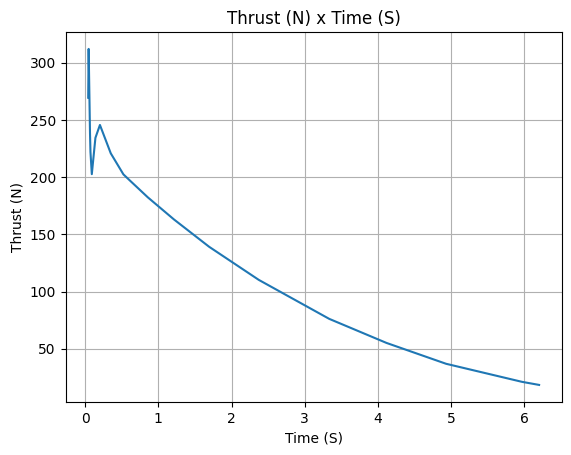

--------------------------------------------------------------------------------
=====SIN EL MOTOR=====


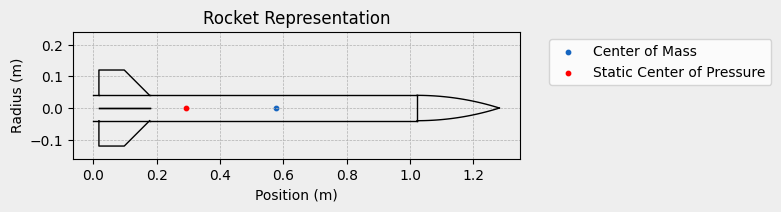


Inertia Details

Rocket Mass: 3.184 kg (without motor)
Rocket Dry Mass: 3.184 kg (with unloaded motor)
Rocket Loaded Mass: 3.184 kg
Rocket Inertia (with unloaded motor) 11: 0.446 kg*m2
Rocket Inertia (with unloaded motor) 22: 0.446 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.005 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.04 m
Rocket Frontal Area: 0.005027 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.000 m
Rocket Center of Dry Mass - Nozzle Exit: 0.577 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.577 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.000 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 9.493/rad

Center of Pressure

Nose Cone Center of Pressure position: 1.162

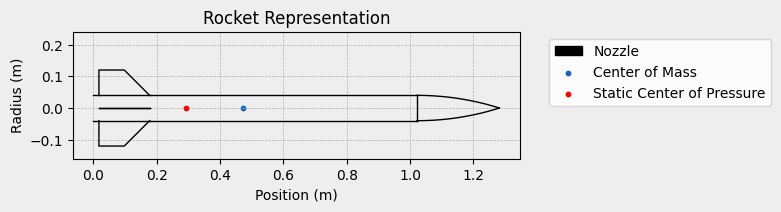


Inertia Details

Rocket Mass: 3.184 kg (without motor)
Rocket Dry Mass: 3.641 kg (with unloaded motor)
Rocket Loaded Mass: 3.991 kg
Rocket Inertia (with unloaded motor) 11: 0.534 kg*m2
Rocket Inertia (with unloaded motor) 22: 0.534 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.005 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.04 m
Rocket Frontal Area: 0.005027 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.058 m
Rocket Center of Dry Mass - Nozzle Exit: 0.519 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.519 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.046 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 9.493/rad

Center of Pressure

Nose Cone Center of Pressure position: 1.162

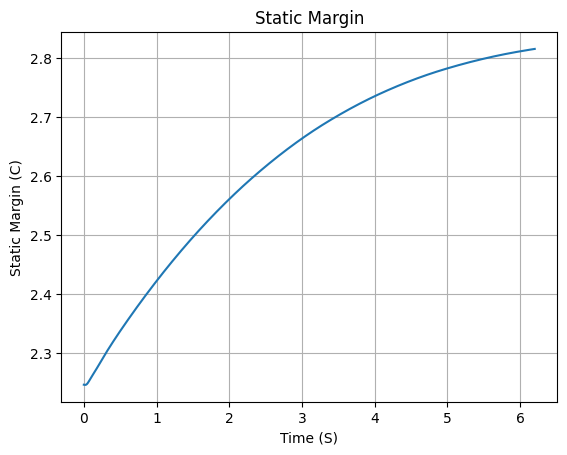

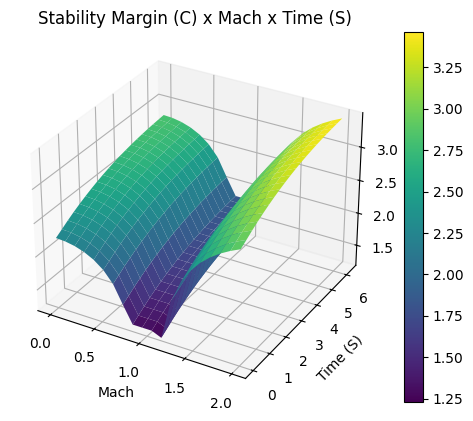

--------------------------------------------------------------------------------


In [2]:
print("--------------------------------------------------------------------------------")

latitud_alcolea = 41.73007275912096

longitud_alcolea = 0.10426577877432051

env = Environment(latitude=latitud_alcolea, longitude=longitud_alcolea, elevation = 186)  # elevación cero porque es a nivel del mar, es en el teleno por que si

env.set_atmospheric_model(type="standard_atmosphere")
env.set_elevation("Open-Elevation")

env.info()

print("--------------------------------------------------------------------------------")
# =============================================================================
# Cesaroni_614I100-17A
# =============================================================================
Motor = GenericMotor(
    thrust_source=r"C:\Users\julfe\Documents\GCULE\Simulacion\Simulaciones_nominales_L1_2_45recto\Cesaroni_614I100-17A.csv", 
    burn_time=(0,6.2), # segundos, introducir el rango de tiempo de combustión sgún aparece en la primera columna del archivo csv
    chamber_radius= 0.027, # radio del motor
    chamber_height= 0.236, # longitud del motor sin contar tobera
    chamber_position= 0, # longitud hasta el culo del motor (desde el culo del cohete, que suele ser la tobera)
    propellant_initial_mass = 0.350, # Kg
    nozzle_radius= 0, 
    dry_mass= 0.457, # kg, masa del motor despues del burn out (sin combustible)
    center_of_dry_mass_position= 0.236/2, # posición de la mitad del motor aprox desde la salida de la tobera
    dry_inertia=(0.00389,0.00389,0.000294152), # KG.M2 con peso en seco, calcular momento de inercia de un cilindro de estas dimensiones y misma masa en seco, se hace en esta pagina web https://www.calcuvio.com/momento-inercia-cilindro
    nozzle_position=0,# 0 si no hay tobera
    coordinate_system_orientation="nozzle_to_combustion_chamber" 
)

Motor.info()
print("--------------------------------------------------------------------------------")

Leon_1_2 = Rocket(
    radius = 0.04, # m, radio exterior
    mass = 3.184, # kg, sin motor
    inertia = (0.4463, 0.4463, 0.004573), # kg*m2, misma asunción que para el motor
    power_off_drag = r"C:\Users\julfe\Documents\GCULE\Simulacion\Simulaciones_nominales_L1_2_45recto\curva_drag_L1_2_45_recto.csv", # ruta de .csv drag RASAERO, pasar a comas
    power_on_drag = r"C:\Users\julfe\Documents\GCULE\Simulacion\Simulaciones_nominales_L1_2_45recto\curva_drag_L1_2_45_recto.csv", # misma ruta que arriba
    center_of_mass_without_motor = 0.576955, # posición del cg en m desde la cola
    coordinate_system_orientation = "tail_to_nose", # dejar como esta
)

# añadir punta
punta_1 = Leon_1_2.add_nose(
    length= 0.26,# longitud ojiva
    kind="tangent", 
    position= 1.282 # longitud total cohete
)

# añadir aletas
aletas_1 = Leon_1_2.add_trapezoidal_fins(
    n=4,
    root_chord = 0.16,
    tip_chord = 0.08,  
    span = 0.08,
    position = 0.178, # cuerda en la raíz + desplazamiento 
    sweep_angle = 45
)
print("=====SIN EL MOTOR=====")
Leon_1_2.draw()
Leon_1_2.info()
print("--------------------------------------------------------------------------------")

Leon_1_2.add_motor(Motor, position=0) # la posición es la longitud de la tobera negativa, poner 0 si no se conoce

print("=====CON EL MOTOR=====")
Leon_1_2.draw()
Leon_1_2.info()
Leon_1_2.plots.static_margin()
Leon_1_2.plots.stability_margin()
print("--------------------------------------------------------------------------------")

main = Leon_1_2.add_parachute(
    name="main",
    cd_s=0.915,
    trigger="apogee",      # ejection altitude in meters
    lag = 3 # tiempo despues de apogeo hasta 17s + 1 segundo de lo que se tarda en abrir (va a haber que bajarlo porque sino 30m/s es demasiado)
)


test_flight = Flight(
    rocket=Leon_1_2, 
    environment=env, 
    rail_length=2.5, 
    inclination=85, 
    heading=0 
    )

In [3]:
print("--------------------------------------------------------------------------------")
test_flight.prints.initial_conditions()
print("--------------------------------------------------------------------------------")
test_flight.prints.surface_wind_conditions()
print("--------------------------------------------------------------------------------")
test_flight.prints.launch_rail_conditions()
print("--------------------------------------------------------------------------------")
test_flight.prints.out_of_rail_conditions()
print("--------------------------------------------------------------------------------")
test_flight.prints.burn_out_conditions()
print("--------------------------------------------------------------------------------")
test_flight.prints.apogee_conditions()
print("--------------------------------------------------------------------------------")
test_flight.prints.events_registered()
print("--------------------------------------------------------------------------------")
test_flight.prints.impact_conditions()
print("--------------------------------------------------------------------------------")
test_flight.prints.maximum_values()
print("--------------------------------------------------------------------------------")

--------------------------------------------------------------------------------

Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 210.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.999 | e1: -0.044 | e2: 0.000 | e3: 0.000
Euler Angles - Spin φ : 0.00° | Nutation θ: -5.00° | Precession ψ: 0.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 2.246 c
--------------------------------------------------------------------------------

Surface Wind Conditions

Frontal Surface Wind Speed: 0.00 m/s
Lateral Surface Wind Speed: 0.00 m/s
--------------------------------------------------------------------------------

Launch Rail

Launch Rail Length: 2.5 m
Launch Rail Inclination: 85.00°
Launch Rail Heading: 0.00°
--------------------------------------------------------------------------------

Rail Departure State

Rail Departure Time: 0.358 s
Rail Departure Velocity: 15.594 m/

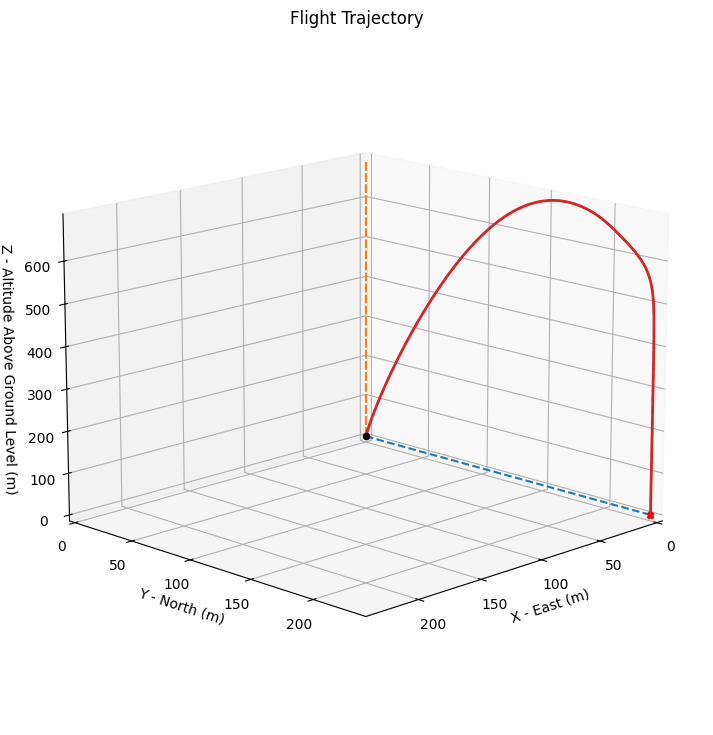

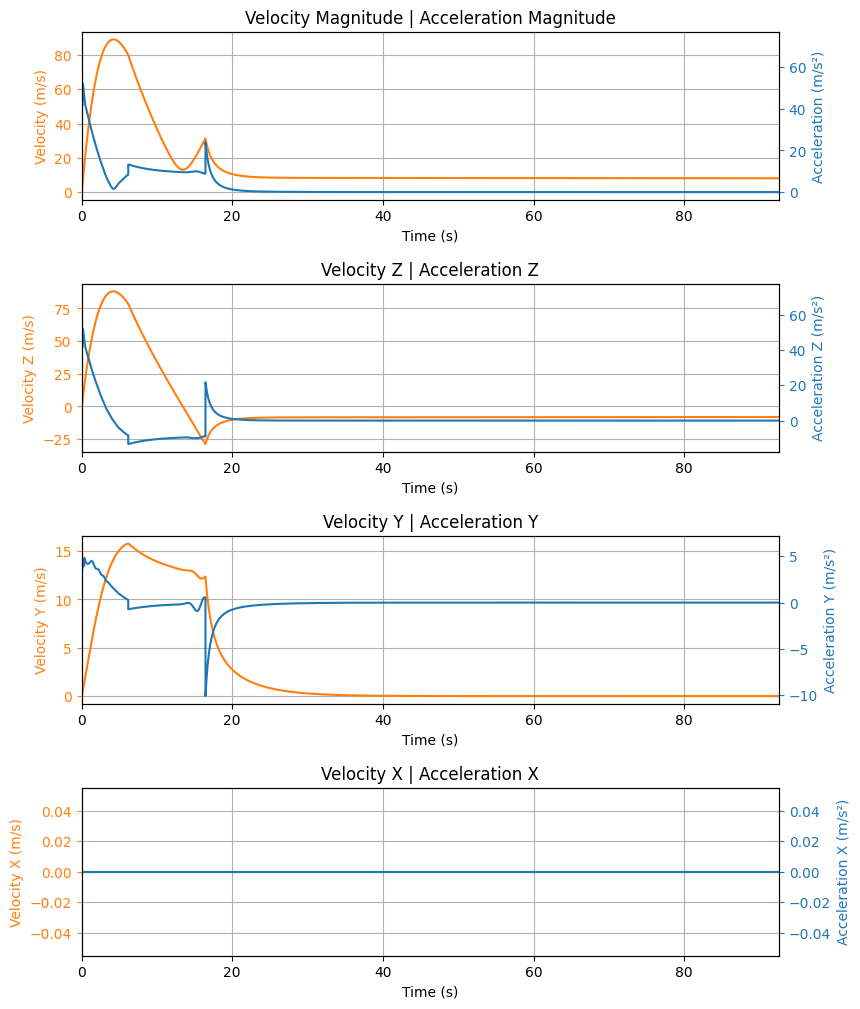

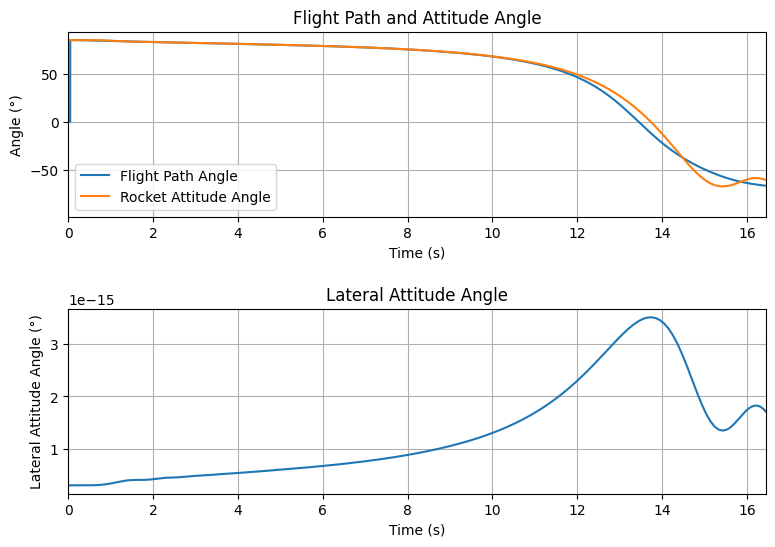

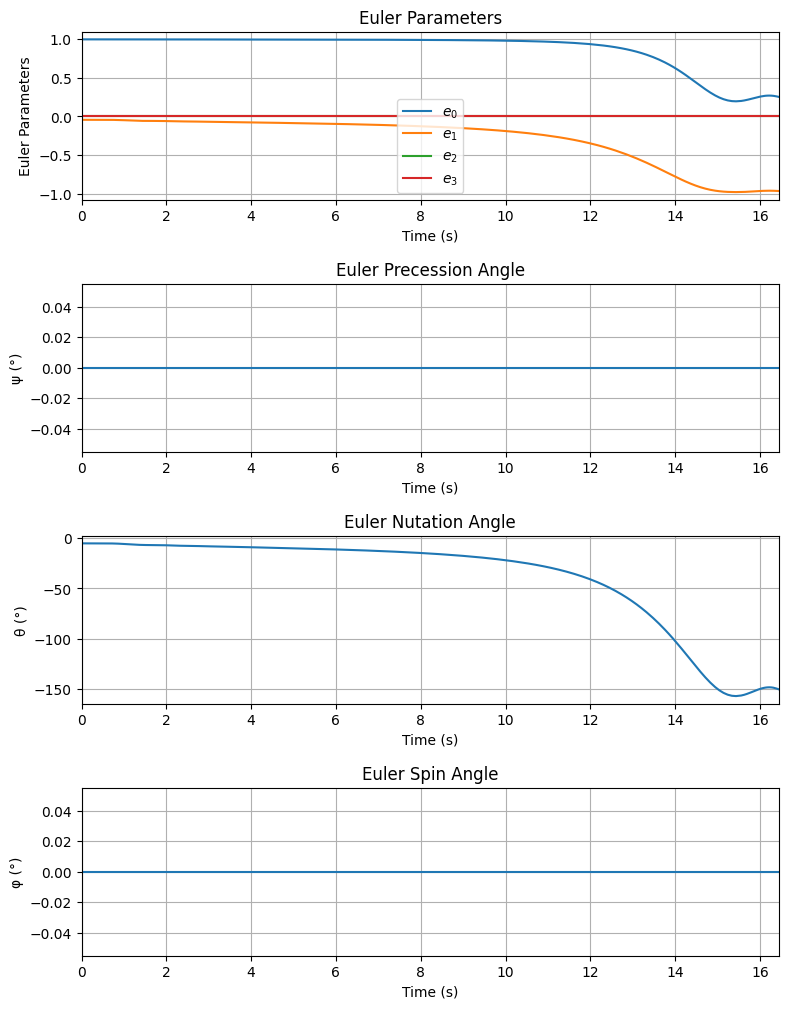

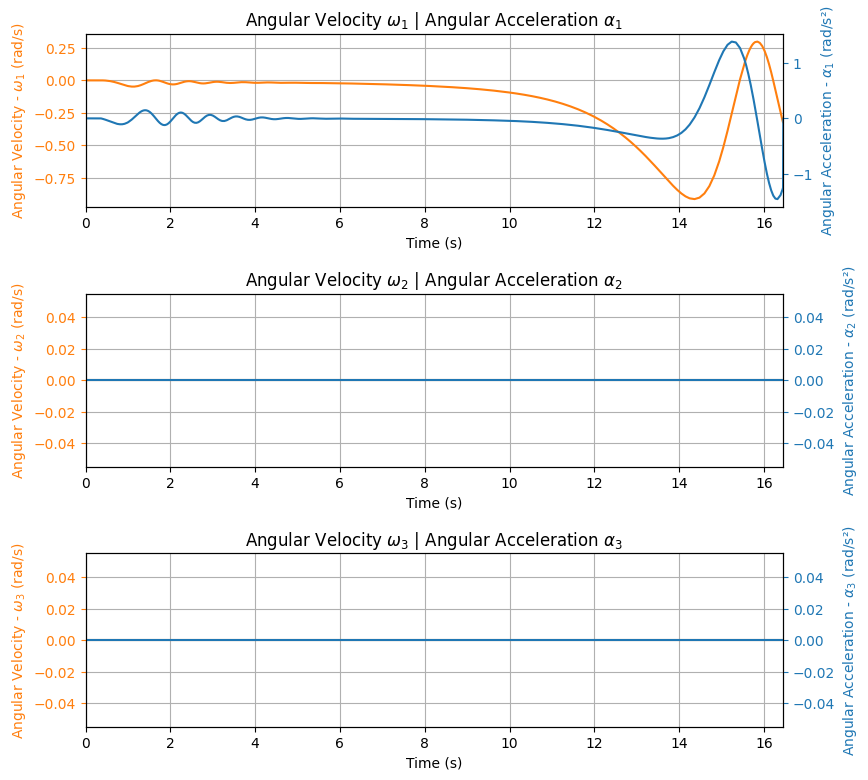

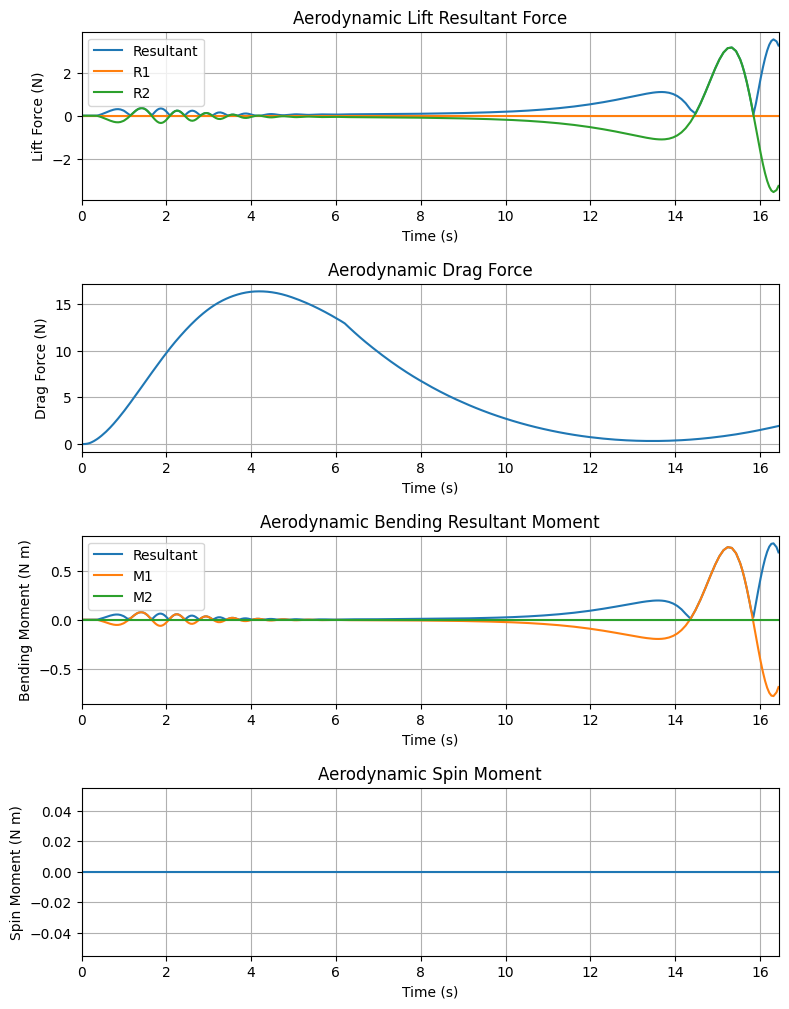

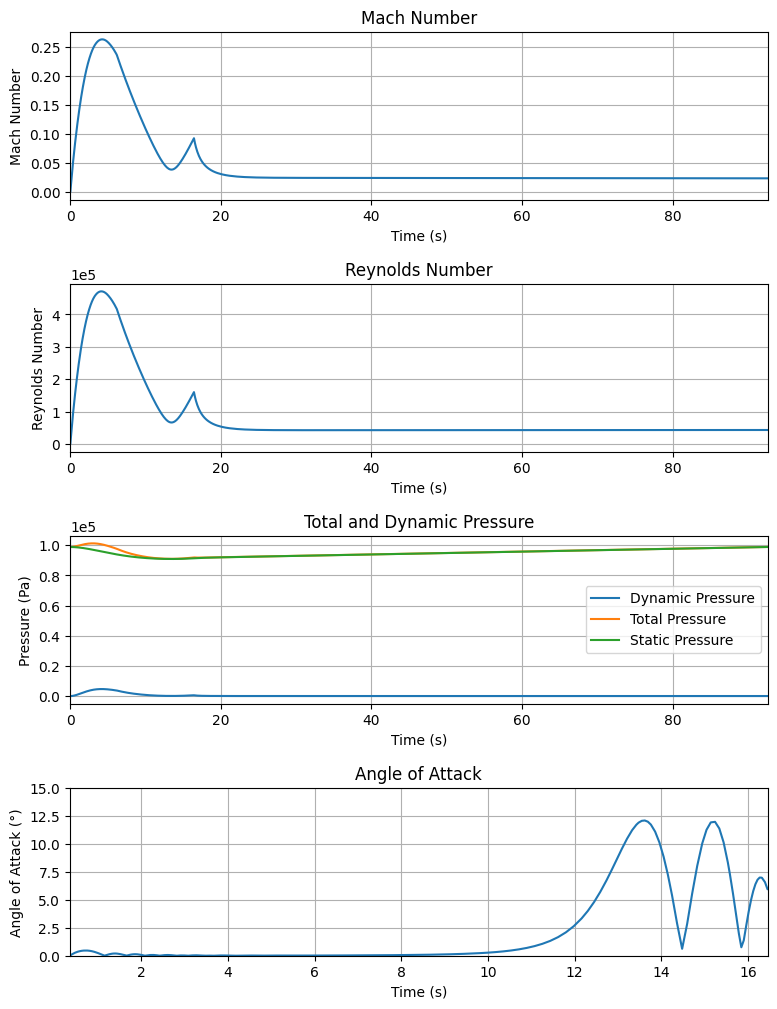

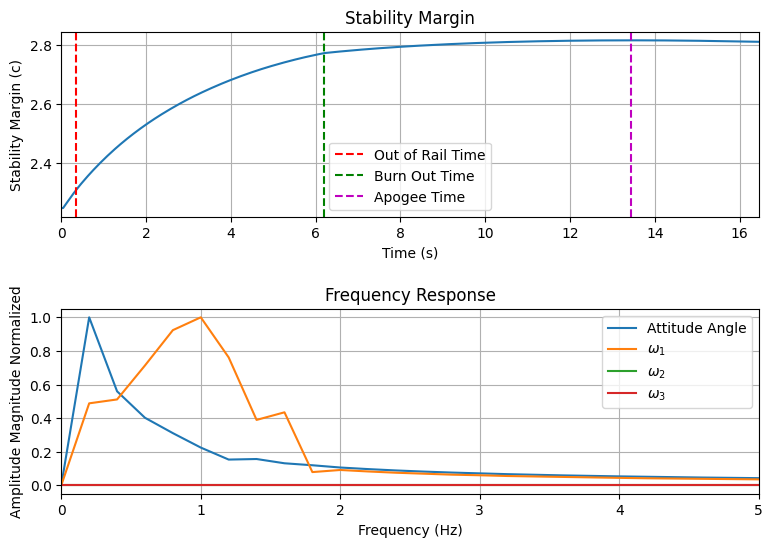

In [4]:
test_flight.plots.trajectory_3d()
test_flight.plots.linear_kinematics_data()
test_flight.plots.flight_path_angle_data()
test_flight.plots.attitude_data()
test_flight.plots.angular_kinematics_data()
test_flight.plots.aerodynamic_forces()
test_flight.plots.fluid_mechanics_data()
test_flight.plots.stability_and_control_data()